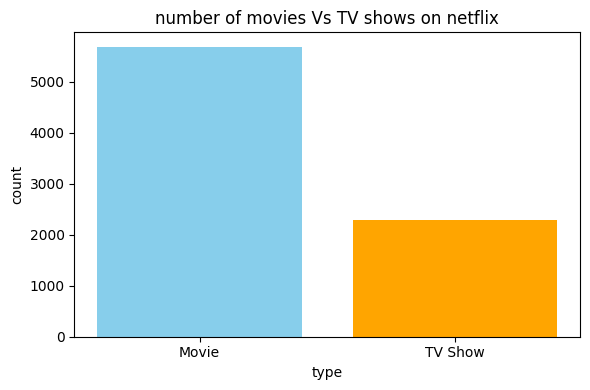

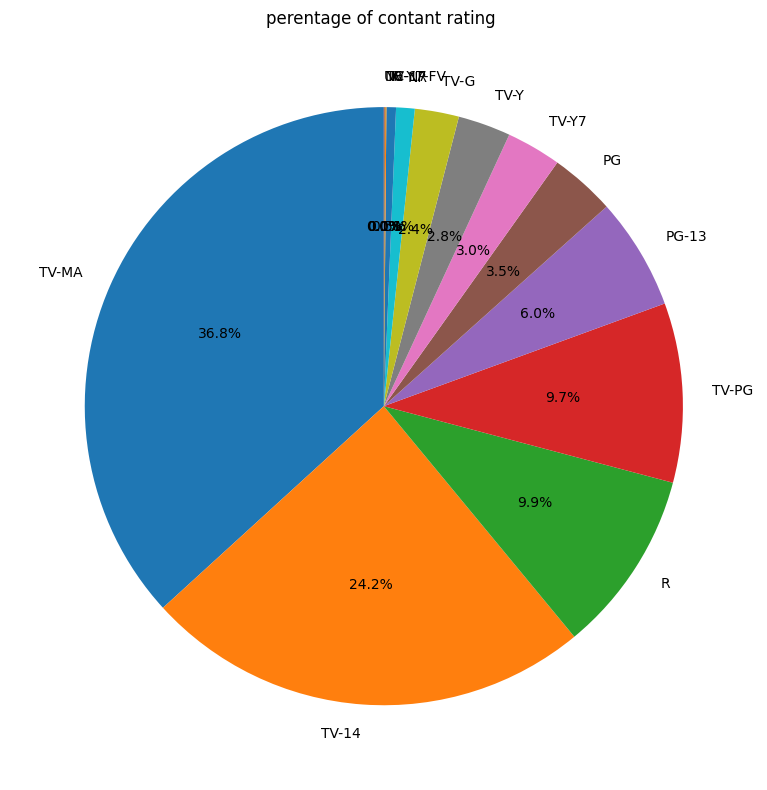

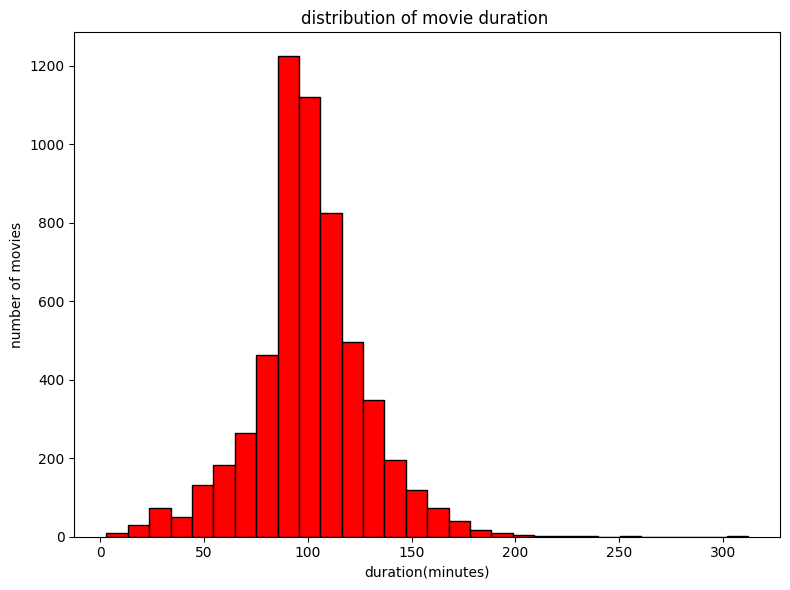

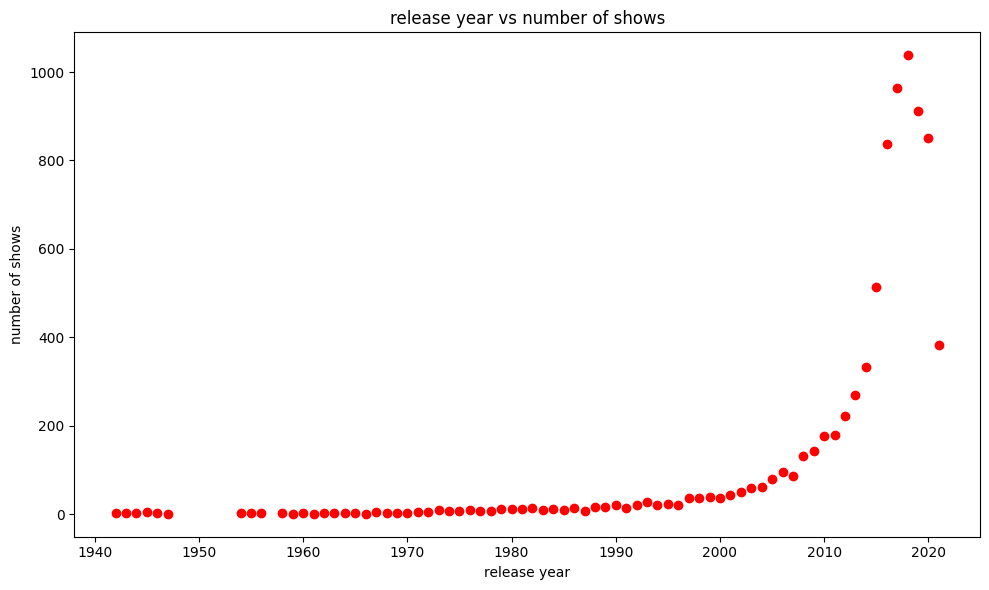

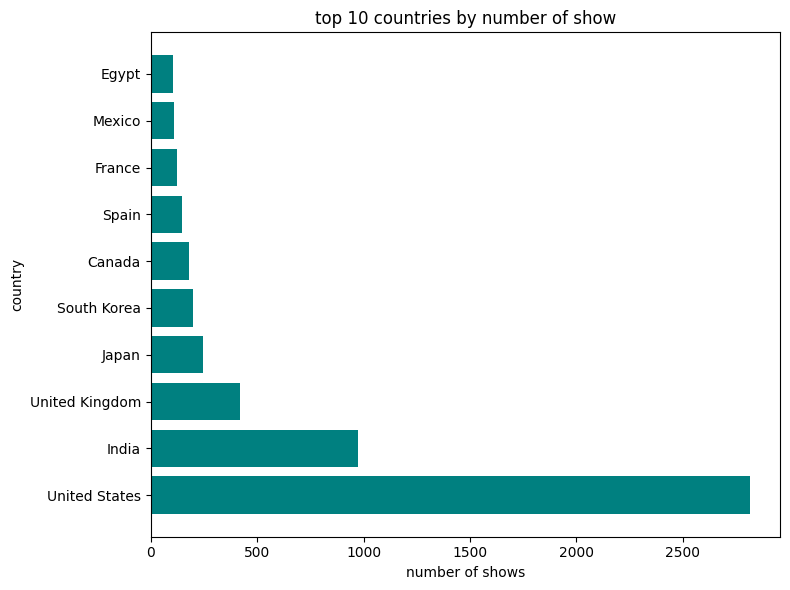

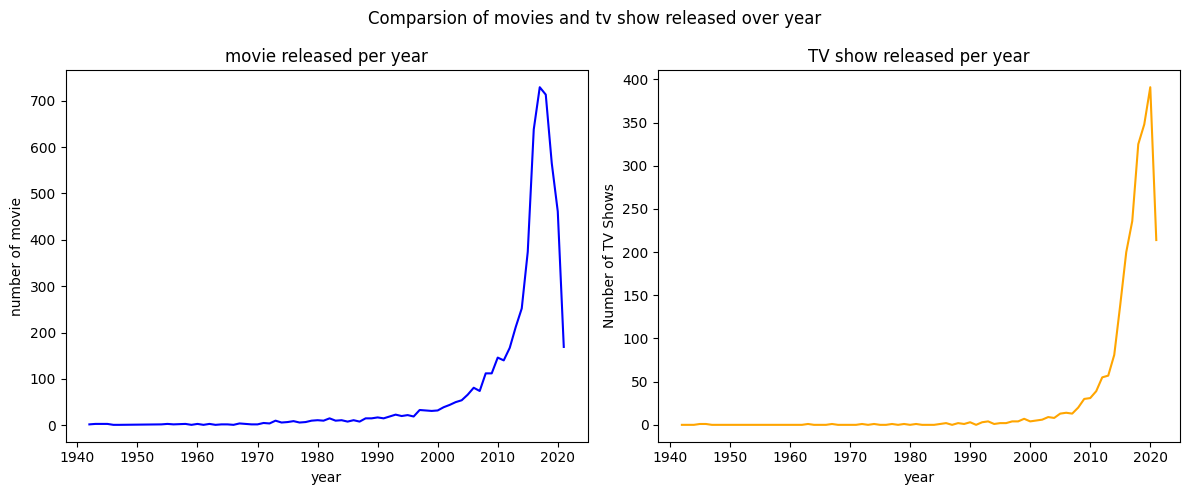

In [3]:
#s- 1 import the libraries
import pandas as pd
import matplotlib.pyplot as plt

#load the data 
df= pd.read_csv('netflix_data_visproject/netflix_titles.csv')

#clean data 
df = df.dropna(subset =['type', 'release_year', 'rating', 'country', 'duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'orange'])
plt.title('number of movies Vs TV shows on netflix')
plt.xlabel('type')
plt.ylabel('count')
plt.tight_layout()
plt.savefig('movies_Vs_tvshows.png')
plt.show()

rating_counts = df['rating'].value_counts()
plt.figure(figsize=(10,8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('perentage of contant rating ')
plt.tight_layout()
plt.savefig('contant_rating_pie.png')
plt.show()

movie_df= df[df['type']== 'Movie'].copy()
movie_df['duration_int']=movie_df['duration'].str.replace('min','').astype(int)
a = movie_df['duration_int']

plt.figure(figsize=(8,6))
plt.hist(a, bins=30, color='red', edgecolor='black')
plt.title('distribution of movie duration ')
plt.xlabel('duration(minutes)')
plt.ylabel('number of movies')
plt.tight_layout()
plt.savefig('movies_duration_histogram.png')
plt.show()

release_counts= df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6)) 
plt.scatter(release_counts.index, release_counts.values, color='red')
plt.title('release year vs number of shows')
plt.xlabel('release year')
plt.ylabel('number of shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()

country_counts= df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color='teal')
 
plt.title('top 10 countries by number of show')
plt.xlabel('number of shows')
plt.ylabel('country')
plt.tight_layout()
plt.savefig('top 10 country.png')
plt.show() 

content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2, figsize=(12,5))

#first subplot:Mpovies

ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title('movie released per year')
ax[0].set_xlabel('year')
ax[0].set_ylabel('number of movie')

#second subplot: TV show

ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[1].set_title('TV show released per year')
ax[1].set_xlabel('year')
ax[1].set_ylabel('Number of TV Shows')

fig.suptitle('Comparsion of movies and tv show released over year')

plt.tight_layout()
plt.savefig('movies_tv_shows_comparsion.png')
plt.show() 


